In [ ]:

from src.agents import AgentSemiGradientSARSAv1
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

seed = 200

env = gym.make("Acrobot-v1", render_mode="None")

n_episodes = 10000

In [5]:
def plot_success_ratio(list_stats_success):
    successes = np.array(list_stats_success)

    cumulative_ratio = np.cumsum(successes) / np.arange(1, len(successes) + 1)

    plt.figure(figsize=(6, 3))
    plt.plot(cumulative_ratio)
    plt.title("Proporción acumulada de éxitos")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de éxitos")
    plt.grid(True)
    plt.show()

def plot_episode_length(episode_lengths):
    y = np.array(episode_lengths, dtype=float)
    x = np.arange(len(y))

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, label="Steps por episodio")


    plt.title("Longitud de episodios")
    plt.xlabel("Episodio")
    plt.ylabel("Steps")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_global_avg(list_stats):
    indices = list(range(len(list_stats)))
    plt.figure(figsize=(8, 4))
    plt.plot(indices, list_stats)
    plt.title("Media acumulada del return")
    plt.xlabel("Episodio")
    plt.ylabel("Return medio acumulado")
    plt.grid(True)
    plt.show()

In [6]:
# 2. Instanciamos nuestro agente de Monte Carlo
agent = AgentSemiGradientSARSAv1(env, alpha=0.2, decay_c=400)

step_display = n_episodes / 10


# ==========================================
# 3. BUCLE DE ENTRENAMIENTO (Lógica SARSA)
# ==========================================
print(f"Entrenando AgentSemiGradientSARSA en {env.spec.id}...")

for episode in tqdm(range(n_episodes)):
    state, info = env.reset(seed=seed)
    
    # SARSA requiere elegir la primera acción ANTES del bucle
    action = agent.get_action(state)
    done = False
    
    while not done:
        # Ejecutamos la acción elegida
        next_state, reward, terminated, truncated, info = env.step(action)
        
        # En SARSA, el update devuelve la SIGUIENTE acción (A')
        # w <- w + alpha [R + gamma*q(S',A',w) - q(S,A,w)] * grad(q)
        next_action = agent.update(state, action, next_state, reward, terminated, truncated, info)
        
        # Avanzamos el estado y la acción
        state = next_state
        action = next_action
        
        done = terminated or truncated

    # Visualización periódica
    if episode % step_display == 0 and episode != 0:
        # stats en tu clase acumula el reward total; lo dividimos por episodios transcurridos
        avg_reward = agent.list_stats[-1] if agent.list_stats else 0
        print(f" Ep: {episode} | Avg Reward: {avg_reward:.2f} | Epsilon: {agent.epsilon:.2f}")


weights, list_stats, episode_lengths, list_stats_success = agent.get_stats()
env.close()

Entrenando AgentSemiGradientSARSA en Acrobot-v1...


 10%|█         | 502/5000 [01:33<12:36,  5.94it/s]

 Ep: 500 | Avg Reward: -497.03 | Epsilon: 0.80


 20%|██        | 1003/5000 [02:36<05:23, 12.35it/s]

 Ep: 1000 | Avg Reward: -405.26 | Epsilon: 0.40


...

 80%|████████  | 4004/5000 [06:01<00:59, 16.85it/s]

 Ep: 4000 | Avg Reward: -229.49 | Epsilon: 0.10


 90%|█████████ | 4503/5000 [06:32<00:31, 15.61it/s]

 Ep: 4500 | Avg Reward: -221.04 | Epsilon: 0.09


100%|██████████| 5000/5000 [07:02<00:00, 11.83it/s]


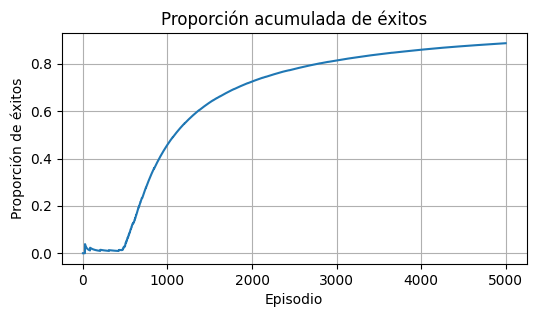

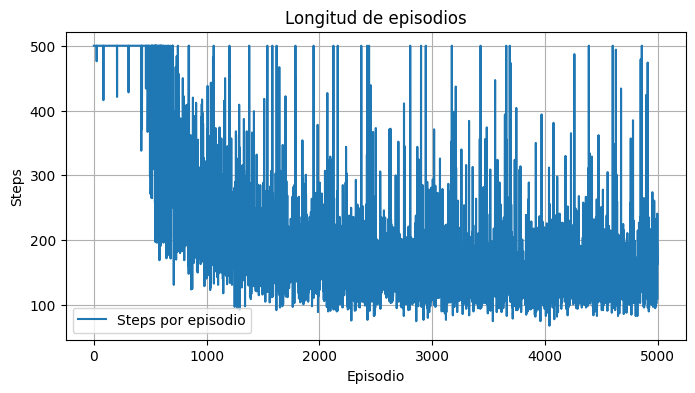

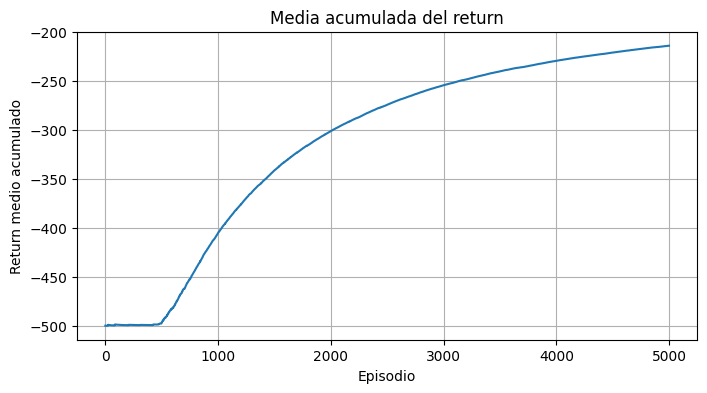

Máxima proporcion: -214.051


In [7]:
#@title Proporción de aciertos por número de episodios

plot_success_ratio(list_stats_success)

plot_episode_length(episode_lengths)

plot_global_avg(list_stats)

print(f"Máxima proporcion: {list_stats[-1]}")